<a href="https://colab.research.google.com/github/CharvatekVit/MPA-MLF_Project/blob/main/Project2_Charvatek_Konar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Imports & Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Imports
import os
import zipfile
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical, plot_model
from IPython.display import display, Image as IPImage
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Paths
TRAIN_ZIP = '/content/drive/MyDrive/Colab Notebooks/MPA-MLF/MPA-MLF_Project/x_train.zip'
TEST_ZIP = '/content/drive/MyDrive/Colab Notebooks/MPA-MLF/MPA-MLF_Project/x_test.zip'
CSV_PATH = '/content/drive/MyDrive/Colab Notebooks/MPA-MLF/MPA-MLF_Project/y_train_v2.csv'
SUB_EXAMPLE = '/content/drive/MyDrive/Colab Notebooks/MPA-MLF/MPA-MLF_Project/y_test_submission_example_v2.csv'
SUB_FINAL = '/content/drive/MyDrive/Colab Notebooks/MPA-MLF/MPA-MLF_Project/final_submission.csv'

TRAIN_DIR = '/content/dataset/train'
TEST_DIR = '/content/dataset/test'

# Config
IMG_W, IMG_H = 51, 45
NUM_CLASSES = 4

Extract Data

In [ ]:
# Extract train data
if not os.path.exists(TRAIN_DIR) or not os.listdir(TRAIN_DIR):
    os.makedirs(TRAIN_DIR, exist_ok=True)
    with zipfile.ZipFile(TRAIN_ZIP, 'r') as z:
        z.extractall(TRAIN_DIR)

# Extract test data
if not os.path.exists(TEST_DIR) or not os.listdir(TEST_DIR):
    os.makedirs(TEST_DIR, exist_ok=True)
    with zipfile.ZipFile(TEST_ZIP, 'r') as z:
        z.extractall(TEST_DIR)

Load & Preprocess Data

In [ ]:
# Load labels
df = pd.read_csv(CSV_PATH)

images, labels = [], []

# Process images
for _, row in df.iterrows():
    # Fix ID offset (CSV starts at 0, images at 1)
    img_path = os.path.join(TRAIN_DIR, f"img_{int(row['id']) + 1}.png")
    if not os.path.exists(img_path):
        img_path = os.path.join(TRAIN_DIR, f"{int(row['id']) + 1}.png")

    if os.path.exists(img_path):
        # Grayscale, resize, normalize
        img = Image.open(img_path).convert('L').resize((IMG_W, IMG_H))
        images.append(np.array(img) / 255.0)
        labels.append(row['target'])

# Format arrays
X = np.array(images).reshape(-1, IMG_H, IMG_W, 1)
y = to_categorical(np.array(labels), num_classes=NUM_CLASSES)

# Train/val split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Visualize Data Samples

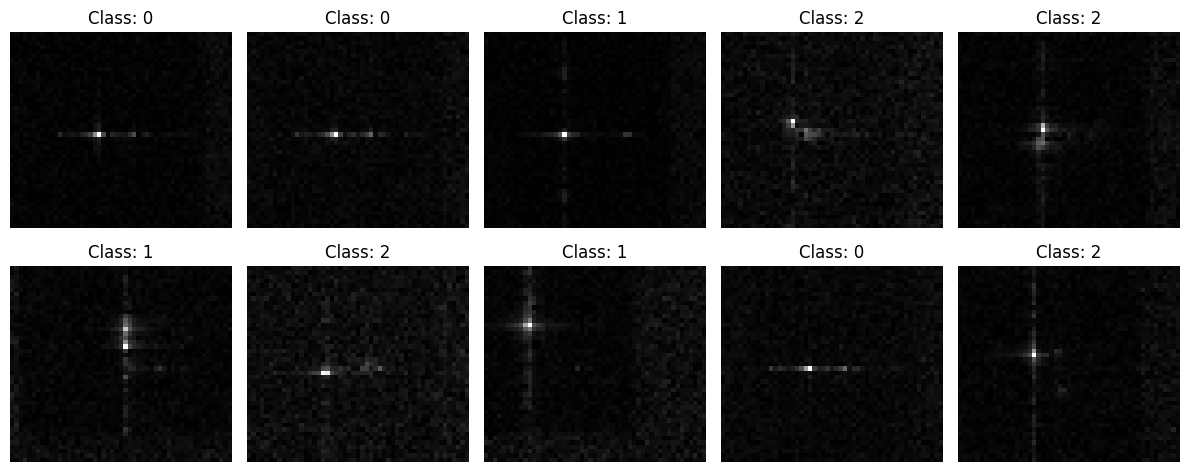

In [ ]:
# Plot 10 random samples
plt.figure(figsize=(12, 5))
for i in range(10):
    idx = np.random.randint(0, len(X_train))
    img = X_train[idx].reshape(IMG_H, IMG_W)
    label = np.argmax(y_train[idx])

    plt.subplot(2, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Class: {label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

Model Architecture & Visualization

Building model with Label Smoothing for extra accuracy...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


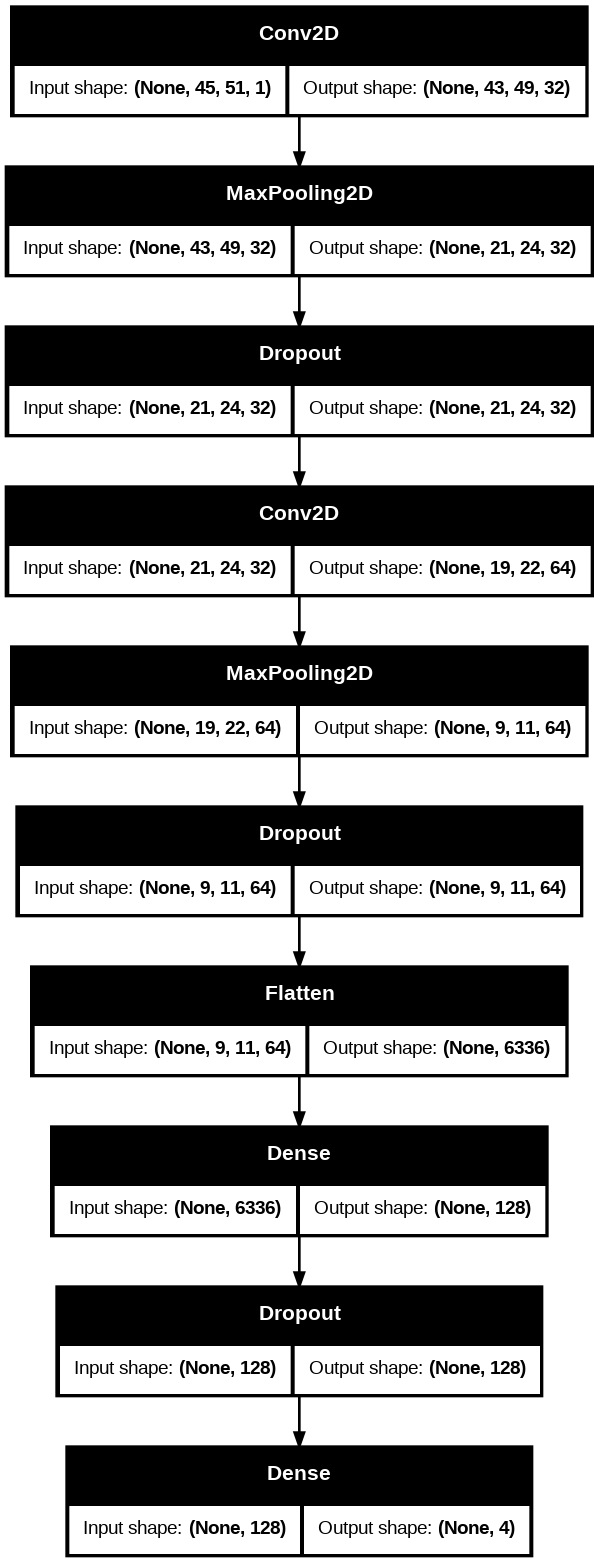

In [ ]:
# Imports
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import CategoricalCrossentropy

print("Building model with Label Smoothing for extra accuracy...")

# CNN matching radar physics
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_H, IMG_W, 1)),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    loss=CategoricalCrossentropy(label_smoothing=0.05),
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

# Plot
plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=False, dpi=96)
display(IPImage('model.png'))

Model Training

In [ ]:
print("Starting Marathon Training...")

# Increased patience and lower minimum LR for deep convergence
early_stop = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7)

# Train with many epochs, trusting early_stop to halt it only if truly stuck
history = model.fit(
    X_train, y_train,
    batch_size=16,
    epochs=600,     # Marathon mode
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr]
)

Starting Marathon Training...
Epoch 1/600
462/462 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9782 - loss: 0.3192 - val_accuracy: 0.9783 - val_loss: 0.3049 - learning_rate: 6.2500e-05
Epoch 2/600
462/462 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9783 - loss: 0.3195 - val_accuracy: 0.9778 - val_loss: 0.3059 - learning_rate: 6.2500e-05
Epoch 3/600
462/462 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9783 - loss: 0.3154 - val_accuracy: 0.9810 - val_loss: 0.3041 - learning_rate: 6.2500e-05
Epoch 4/600
462/462 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9786 - loss: 0.3197 - val_accuracy: 0.9772 - val_loss: 0.3026 - learning_rate: 6.2500e-05
Epoch 5/600
462/462 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9789 - loss: 0.3171 - val_accuracy: 0.9772 - val_loss: 0.3056 - learning_rate: 6.2500e-05
Epoch 6/600
462/462 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9797 - loss: 0.3168 - val_accuracy: 0.9767 - val_loss: 0.3096 - learning_rate: 6.2500e-05
Epoch 7/600
462/462 ━━━━━━━━

58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


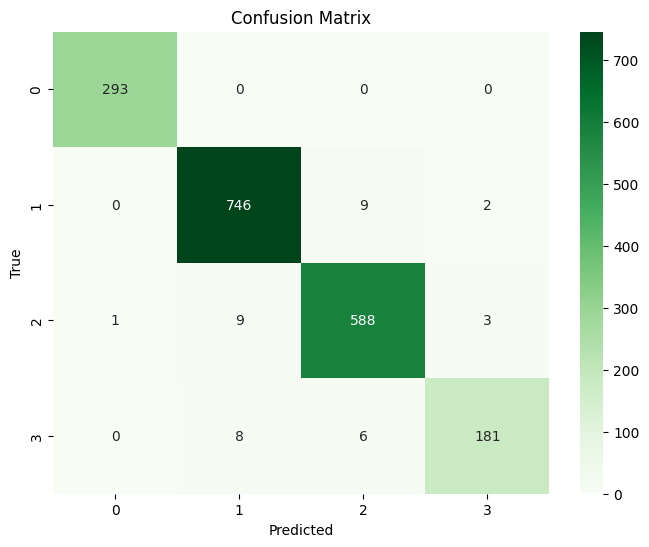

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       293
           1       0.98      0.99      0.98       757
           2       0.98      0.98      0.98       601
           3       0.97      0.93      0.95       195

    accuracy                           0.98      1846
   macro avg       0.98      0.97      0.98      1846
weighted avg       0.98      0.98      0.98      1846



In [ ]:
# Predict
y_pred = np.argmax(model.predict(X_val), axis=1)
y_true = np.argmax(y_val, axis=1)

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

# Report
print(classification_report(y_true, y_pred))

Kaggle Submission

In [ ]:
# Natural sort helper
def natural_sort(s):
    return [int(t) if t.isdigit() else t.lower() for t in re.split('([0-9]+)', s)]

# Sort test files
test_files = sorted([f for f in os.listdir(TEST_DIR) if f.endswith('.png')], key=natural_sort)

# Load submission template
sub_df = pd.read_csv(SUB_EXAMPLE).sort_values('id').reset_index(drop=True)

# Process test images
test_imgs = []
for f in test_files:
    img = Image.open(os.path.join(TEST_DIR, f)).convert('L').resize((IMG_W, IMG_H))
    test_imgs.append(np.array(img) / 255.0)

X_test = np.array(test_imgs).reshape(-1, IMG_H, IMG_W, 1)

# Predict & Save
sub_df['target'] = np.argmax(model.predict(X_test), axis=1)
sub_df.to_csv(SUB_FINAL, index=False)

print(f"Saved to: {SUB_FINAL}")

124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Saved to: /content/drive/MyDrive/Colab Notebooks/MPA-MLF/MPA-MLF_Project/final_submission.csv
